<a href="https://colab.research.google.com/github/oj3v0ns/MMM/blob/main/With_copilot_help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mediated model

In [ ]:
# SEM-MEDIATED MMM (PyMC 5)
# Hybrid architecture:
#   - Upper → Lower: linear with 1-week lag
#   - Upper → Brand: linear with 2-week lag
#   - Sales: adstock + Hill for Upper & Lower (no explicit lag), Brand linear
#   - Fourier seasonality (period=52, K=3)
#
# Outputs:
#   - Posterior predictive mean vs actual (PNG)
#   - R2, MAPE
#   - Decomposition time series (upper total; lower own)
#   - Waterfall of total contributions
#
# Requirements: pip install pymc arviz pandas numpy matplotlib openpyxl xarray
# Note: code uses PyMC v5 APIs (pm.Data, predictions=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import xarray as xr
import warnings
import pytensor.tensor as pt

warnings.filterwarnings("ignore")

In [ ]:
# -------------------- USER SETTINGS --------------------
DATA_URL = "https://github.com/oj3v0ns/MMM/raw/01b4ffe457af67b60e2cc414c4171dd8d3e9a15f/Project%20Input%20Data.xlsx"

upper_channels = ["TV_GRP", "Influencers_Views"]
lower_channels = [
    "Google_Display_Impressions",
    "Meta_Impressions",
    "Google_Generic_Paid_Search_Impressions",
    "Google_Brand_Paid_Search_Clicks",
    "YouTube_Impressions",
]
dv_col = "Accounts Subscriptions"
brand_col = "brand_consideration"

# Lags (as agreed)
LAG_U_TO_L = 1   # weeks
LAG_U_TO_B = 2   # weeks

# Adstock window (weeks) for convolution
ADSTOCK_WINDOW_WEEKS = 13

# Fourier seasonality
FOURIER_ORDER_K = 3
SEASONAL_PERIOD = 52

# Sampling
random_seed = 2026
draws = 1500
tune = 1500
target_accept = 0.9
chains = 4

In [ ]:
# -------------------- HELPERS --------------------
def load_and_prepare(url, uppers, lowers, dv, brand):
    df = pd.read_excel(url, engine="openpyxl")
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    need = uppers + lowers + [dv, brand]
    missing = [c for c in need if c not in numeric_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    known = set(need)
    control_cols = [c for c in numeric_df.columns if c not in known]
    numeric_df = numeric_df.dropna(subset=need)

    return numeric_df, control_cols

def zscore(df, cols):
    means = df[cols].mean()
    stds = df[cols].std(ddof=0).replace(0, 1.0)
    z = (df[cols] - means) / stds
    return z, means, stds

def scale_nonneg_unit(x):
    """Map series/array to [0,1] (robust) for Hill; avoid negatives.
       Uses min and 98th percentile to reduce outlier influence."""
    x = np.asarray(x, dtype=float)
    lo = np.nanmin(x)
    hi = np.nanpercentile(x, 98)
    if hi - lo <= 0:
        return np.zeros_like(x), lo, hi
    return (x - lo) / (hi - lo), lo, hi

def build_fourier(T, K=3, period=52):
    t = np.arange(T)
    X = []
    names = []
    for k in range(1, K+1):
        X.append(np.sin(2*np.pi*k*t/period)); names.append(f"sin_{k}")
        X.append(np.cos(2*np.pi*k*t/period)); names.append(f"cos_{k}")
    X = np.column_stack(X) if len(X) > 0 else np.zeros((T, 0))
    return X, names

def build_lag_matrix(x, max_lag):
    """Return (T, max_lag) where column l is x shifted by l (pad with 0)."""
    x = np.asarray(x).reshape(-1)
    T = len(x)
    mat = np.zeros((T, max_lag))
    for l in range(max_lag):
        if l == 0:
            mat[:, l] = x
        else:
            mat[l:, l] = x[:-l]
    return mat

# ---- PyTensor (pt) versions to replace pm.math.* ----
def build_adstock_from_lagmat(lag_mat, theta):
    """lag_mat: (T, W) tensor; theta in (0,1); returns (T,) adstocked signal."""
    W = lag_mat.shape[1]
    w = pt.pow(theta, pt.arange(W))  # (W,)
    return pt.dot(lag_mat, w)        # (T,)

def hill_saturation(x, alpha, k, eps=1e-8):
    """x >= 0; returns (0,1) saturation."""
    x_pos = pt.maximum(x, 0.0) + eps
    num = pt.pow(x_pos, alpha)
    den = num + pt.pow(pt.maximum(k, eps), alpha)
    return num / (den + eps)

def compute_r2_mape(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
    return r2, mape

def posterior_mean(obj, name):
    return obj.posterior[name].mean(dim=("chain", "draw")).values

def posterior_pred_mean(ppc, name):
    da = ppc.predictions[name]
    return np.asarray(da.mean(dim=("chain", "draw"))).reshape(-1)

def waterfall(ax, labels, values, title):
    colors = [("#2E86AB" if v >= 0 else "#C70039") for v in values[:-1]] + ["#6C3483"]
    running = [0]
    for v in values[:-1]:
        running.append(running[-1] + v)
    for i, v in enumerate(values[:-1]):
        ax.bar(labels[i], v, bottom=running[i], color=colors[i])
    ax.bar(labels[-1], values[-1], color=colors[-1])
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Sales (original units)")
    ax.set_xticklabels(labels, rotation=45, ha="right")

In [ ]:
# -------------------- LOAD & PREP --------------------
df, control_cols = load_and_prepare(DATA_URL, upper_channels, lower_channels, dv_col, brand_col)

# Determine max mediation lag to align series
MAX_MEDIATION_LAG = max(LAG_U_TO_L, LAG_U_TO_B)  # = 2
df = df.iloc[MAX_MEDIATION_LAG:].reset_index(drop=True)

# Standardize series for equations that need z-scores
X_u_z, u_mean, u_std = zscore(df, upper_channels)
X_l_z, l_mean, l_std = zscore(df, lower_channels)
y_z, y_mean, y_std = zscore(df, [dv_col])
b_z, b_mean, b_std = zscore(df, [brand_col])

# Controls standardized (for stability)
if len(control_cols) > 0:
    X_c_z, c_mean, c_std = zscore(df, control_cols)
    Cz = X_c_z.values  # (T, n_c)
else:
    Cz = np.zeros((len(df), 0))

U_z = X_u_z.values  # (T, n_u)
L_z = X_l_z.values  # (T, n_l)
Bz = b_z.values.reshape(-1)  # (T,)
Yz = y_z.values.reshape(-1)  # (T,)

T = len(df)
n_u = len(upper_channels)
n_l = len(lower_channels)
n_c = Cz.shape[1]

# Build lagged U for mediation equations
U_z_lag1 = np.vstack([np.zeros((1, n_u)), U_z[:-1, :]])      # U→L (1 week)
U_z_lag2 = np.vstack([np.zeros((2, n_u)), U_z[:-2, :]])      # U→B (2 weeks)

# Fourier seasonality (used as controls in all equations)
S_fourier, fourier_names = build_fourier(T, K=FOURIER_ORDER_K, period=SEASONAL_PERIOD)
n_seas = S_fourier.shape[1]

# Non-negative scaled versions for adstock+hill (for sales eq)
U_nonneg = []
L_nonneg = []
for ch in upper_channels:
    xi, _, _ = scale_nonneg_unit(df[ch].values)
    U_nonneg.append(xi)
for ch in lower_channels:
    xj, _, _ = scale_nonneg_unit(df[ch].values)
    L_nonneg.append(xj)
U_nonneg = np.column_stack(U_nonneg)  # (T, n_u)
L_nonneg = np.column_stack(L_nonneg)  # (T, n_l)

# Lag matrices for adstock convolution (pad with zeros automatically)
U_lagmats = [build_lag_matrix(U_nonneg[:, i], ADSTOCK_WINDOW_WEEKS) for i in range(n_u)]  # list of (T,W)
L_lagmats = [build_lag_matrix(L_nonneg[:, j], ADSTOCK_WINDOW_WEEKS) for j in range(n_l)]

In [ ]:
# -------------------- MODEL --------------------
with pm.Model() as sem_model:
    # Data containers (store returned shared variables to reuse below)
    U_z_v        = pm.Data("U_z", U_z)
    L_z_v        = pm.Data("L_z", L_z)
    Bz_v         = pm.Data("Bz", Bz)
    Yz_v         = pm.Data("Yz", Yz)
    U_z_lag1_v   = pm.Data("U_z_lag1", U_z_lag1)
    U_z_lag2_v   = pm.Data("U_z_lag2", U_z_lag2)
    Cz_v         = pm.Data("Cz", Cz)
    S_fourier_v  = pm.Data("S_fourier", S_fourier)

    # ====== Lower funnel equations:
    # L_z[:, j] ~ a_lj + U_z_lag1 @ B_ul[:,j] + Cz @ Gamma_l[:,j] + S @ S_l[:,j] + ε_lj
    a_l   = pm.Normal("a_l", 0.0, 1.0, shape=n_l)
    B_ul  = pm.HalfNormal("B_ul", sigma=1.0, shape=(n_u, n_l))  # positive mediation U->L
    if n_c > 0:
        Gamma_l = pm.Normal("Gamma_l", 0.0, 1.0, shape=(n_c, n_l))
    S_l   = pm.Normal("S_l", 0.0, 0.5, shape=(n_seas, n_l))
    sigma_l = pm.HalfNormal("sigma_l", 1.0, shape=n_l)

    mu_L = a_l + pt.dot(U_z_lag1_v, B_ul) + pt.dot(S_fourier_v, S_l)
    if n_c > 0:
        mu_L = mu_L + pt.dot(Cz_v, Gamma_l)
    pm.Normal("L_obs", mu=mu_L, sigma=sigma_l, observed=L_z_v)

    # ====== Brand equation:
    # Bz ~ a_b + U_z_lag2 @ B_ub + Cz @ Gamma_b + S @ S_b + ε_b
    a_b   = pm.Normal("a_b", 0.0, 1.0)
    B_ub  = pm.HalfNormal("B_ub", sigma=1.0, shape=n_u)  # positive U->Brand
    if n_c > 0:
        Gamma_b = pm.Normal("Gamma_b", 0.0, 1.0, shape=n_c)
    S_b   = pm.Normal("S_b", 0.0, 0.5, shape=n_seas)
    sigma_b = pm.HalfNormal("sigma_b", 1.0)

    mu_B = a_b + pt.dot(U_z_lag2_v, B_ub) + pt.dot(S_fourier_v, S_b)
    if n_c > 0:
        mu_B = mu_B + pt.dot(Cz_v, Gamma_b)
    pm.Normal("B_obs", mu=mu_B, sigma=sigma_b, observed=Bz_v)

    # ====== Sales equation with adstock + Hill on U & L, Brand linear
    a_s   = pm.Normal("a_s", 0.0, 1.0)

    # Media priors (positive effects)
    beta_u = pm.HalfNormal("beta_u", sigma=1.0, shape=n_u)
    beta_l = pm.HalfNormal("beta_l", sigma=1.0, shape=n_l)
    beta_b = pm.HalfNormal("beta_b", sigma=1.0)  # brand positive

    # Controls & seasonality in sales
    if n_c > 0:
        gamma_s = pm.Normal("gamma_s", 0.0, 1.0, shape=n_c)
    S_s = pm.Normal("S_s", 0.0, 0.5, shape=n_seas)

    # Adstock/Hill parameters per channel
    theta_u = pm.Beta("theta_u", alpha=2.0, beta=2.0, shape=n_u)  # (0,1)
    theta_l = pm.Beta("theta_l", alpha=2.0, beta=2.0, shape=n_l)
    alpha_u = pm.HalfNormal("alpha_u", sigma=1.0, shape=n_u) + 0.5  # >0
    alpha_l = pm.HalfNormal("alpha_l", sigma=1.0, shape=n_l) + 0.5
    k_u     = pm.HalfNormal("k_u", sigma=1.0, shape=n_u) + 1e-3      # >0
    k_l     = pm.HalfNormal("k_l", sigma=1.0, shape=n_l) + 1e-3

    # Precomputed lag matrices as numpy; wrap as pm.Data once and REUSE
    U_lagdat = [pm.Data(f"U_lagmat_{i}", U_lagmats[i]) for i in range(n_u)]
    L_lagdat = [pm.Data(f"L_lagmat_{j}", L_lagmats[j]) for j in range(n_l)]

    # Construct transformed regressors (use pt ops)
    U_trans = []
    for i in range(n_u):
        ad_u = build_adstock_from_lagmat(U_lagdat[i], theta_u[i])
        su   = hill_saturation(ad_u, alpha_u[i], k_u[i])
        U_trans.append(su)
    L_trans = []
    for j in range(n_l):
        ad_l = build_adstock_from_lagmat(L_lagdat[j], theta_l[j])
        sl   = hill_saturation(ad_l, alpha_l[j], k_l[j])
        L_trans.append(sl)

    U_trans = pt.stack(U_trans, axis=1)  # (T, n_u)
    L_trans = pt.stack(L_trans, axis=1)  # (T, n_l)

    mu_Y = (
        a_s
        + pt.dot(U_trans, beta_u)
        + pt.dot(L_trans, beta_l)
        + Bz_v * beta_b
        + pt.dot(S_fourier_v, S_s)
    )
    if n_c > 0:
        mu_Y = mu_Y + pt.dot(Cz_v, gamma_s)

    sigma_s = pm.HalfNormal("sigma_s", 1.0)
    pm.Normal("y_obs", mu=mu_Y, sigma=sigma_s, observed=Yz_v)

    # Sample
    trace = pm.sample(
        draws=draws, tune=tune, chains=chains,
        target_accept=target_accept, random_seed=random_seed, progressbar=True
    )
    ppc = pm.sample_posterior_predictive(trace, predictions=True, random_seed=random_seed)

Output()

ERROR:pymc.stats.convergence:There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

[SEM-Mediated] R² = 0.883 | MAPE = 6.56%


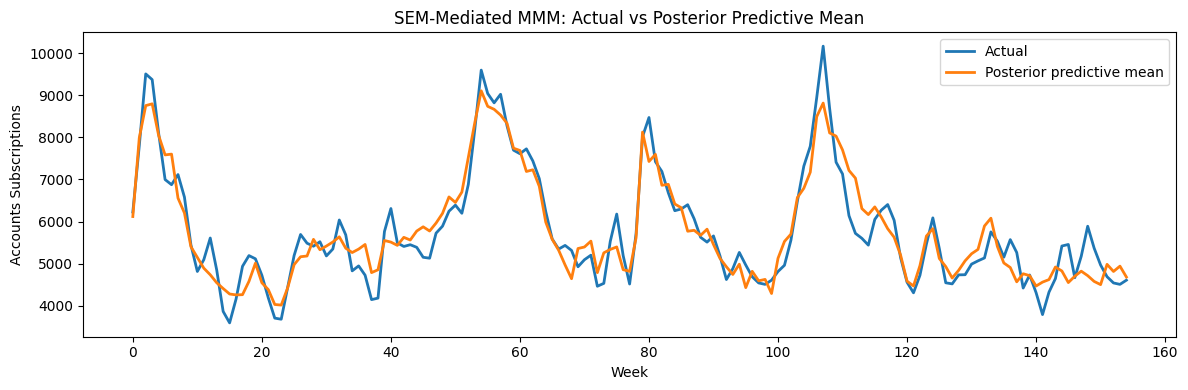

In [ ]:
# -------------------- DIAGNOSTICS --------------------
y_pred_z = posterior_pred_mean(ppc, "y_obs")  # (T,)
y_pred = y_pred_z * float(y_std[dv_col]) + float(y_mean[dv_col])
y_actual = df[dv_col].values

r2, mape = compute_r2_mape(y_actual, y_pred)
print(f"[SEM-Mediated] R² = {r2:.3f} | MAPE = {mape:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(y_actual, label="Actual", lw=2)
plt.plot(y_pred, label="Posterior predictive mean", lw=2)
plt.title("SEM-Mediated MMM: Actual vs Posterior Predictive Mean")
plt.xlabel("Week")
plt.ylabel("Accounts Subscriptions")
plt.legend()
plt.tight_layout()
plt.savefig("sem_mediated_actual_vs_pred.png", dpi=160)

In [ ]:
# -------------------- DECOMPOSITION --------------------
# Posterior mean params
coef = {}
for name in ["a_s","beta_u","beta_l","beta_b","a_l","B_ul","a_b","B_ub","S_s","S_l","S_b"]:
    coef[name] = posterior_mean(trace, name)
if n_c > 0:
    for name in ["gamma_s","Gamma_l","Gamma_b"]:
        coef[name] = posterior_mean(trace, name)

# Rebuild transformed regressors at posterior mean thetas/alphas/k
theta_u_m = posterior_mean(trace, "theta_u")
theta_l_m = posterior_mean(trace, "theta_l")
alpha_u_m = posterior_mean(trace, "alpha_u")
alpha_l_m = posterior_mean(trace, "alpha_l")
k_u_m = posterior_mean(trace, "k_u")
k_l_m = posterior_mean(trace, "k_l")

# Adstock + Hill (deterministic, using means) for decomposition
def adstock_numpy(lagmat, theta):
    W = lagmat.shape[1]
    w = theta ** np.arange(W)
    return lagmat @ w

U_trans_np = []
for i in range(n_u):
    ad = adstock_numpy(U_lagmats[i], theta_u_m[i])
    sat = (np.maximum(ad, 0.0) ** alpha_u_m[i]) / (np.maximum(ad, 0.0) ** alpha_u_m[i] + (k_u_m[i] ** alpha_u_m[i]) + 1e-8)
    U_trans_np.append(sat)
U_trans_np = np.column_stack(U_trans_np)  # (T,n_u)

L_trans_np = []
for j in range(n_l):
    ad = adstock_numpy(L_lagmats[j], theta_l_m[j])
    sat = (np.maximum(ad, 0.0) ** alpha_l_m[j]) / (np.maximum(ad, 0.0) ** alpha_l_m[j] + (k_l_m[j] ** alpha_l_m[j]) + 1e-8)
    L_trans_np.append(sat)
L_trans_np = np.column_stack(L_trans_np)  # (T,n_l)

ys = float(y_std[dv_col])
ym = float(y_mean[dv_col])

# Direct contributions in original units
contrib_upper_direct = {ch: (coef["beta_u"][i] * U_trans_np[:, i]) * ys for i, ch in enumerate(upper_channels)}
contrib_lower_direct = {ch: (coef["beta_l"][j] * L_trans_np[:, j]) * ys for j, ch in enumerate(lower_channels)}
contrib_brand_total = (coef["beta_b"] * Bz) * ys

# Seasonality, controls, intercept
contrib_seasonality = (S_fourier @ coef["S_s"]) * ys
contrib_controls = (Cz @ coef["gamma_s"]) * ys if n_c > 0 else np.zeros(T)
contrib_intercept = np.full(T, coef["a_s"] * ys + ym)

# ---- Mediation allocation (proportional via mediation equations) ----
contrib_upper_via_lower = {u: np.zeros(T) for u in upper_channels}

# compute shares per lower channel j at each t
for j, lower_ch in enumerate(lower_channels):
    # Numerators for each upper i: abs(U_lag1[:, i] * B_ul[i, j])
    nums = np.abs(U_z_lag1 * coef["B_ul"][:, j])  # (T, n_u)
    den = np.sum(nums, axis=1) + 1e-8            # (T,)
    shares = nums / den[:, None]                  # (T, n_u)

    # Sales contribution of this lower channel
    lower_contrib_t = (coef["beta_l"][j] * L_trans_np[:, j]) * ys  # (T,)

    for i, u_ch in enumerate(upper_channels):
        contrib_upper_via_lower[u_ch] += shares[:, i] * lower_contrib_t

# Brand: allocate fraction of brand contribution to uppers using U→B eq
nums_b = np.abs(U_z_lag2 * coef["B_ub"])  # (T, n_u)
den_b = np.sum(nums_b, axis=1) + 1e-8
shares_b = nums_b / den_b[:, None]        # (T, n_u)

contrib_upper_via_brand = {u: shares_b[:, i] * contrib_brand_total for i, u in enumerate(upper_channels)}
sum_brand_from_upper = np.sum(np.column_stack(list(contrib_upper_via_brand.values())), axis=1)
contrib_brand_residual = contrib_brand_total - sum_brand_from_upper

# Lower own-only (remove part attributed to uppers)
contrib_lower_own = {}
for j, lower_ch in enumerate(lower_channels):
    lower_total = contrib_lower_direct[lower_ch]
    nums = np.abs(U_z_lag1 * coef["B_ul"][:, j])
    den = np.sum(nums, axis=1) + 1e-8
    shares = nums / den[:, None]
    allocated = np.zeros(T)
    for i in range(n_u):
        allocated += shares[:, i] * ((coef["beta_l"][j] * L_trans_np[:, j]) * ys)
    contrib_lower_own[lower_ch] = lower_total - allocated

# Upper total = direct + via lower + via brand
contrib_upper_total = {}
for u in upper_channels:
    contrib_upper_total[u] = contrib_upper_direct[u] + contrib_upper_via_lower[u] + contrib_upper_via_brand[u]

Saved figures: sem_mediated_actual_vs_pred.png, sem_mediated_upper_contributions_timeseries.png, sem_mediated_lower_contributions_timeseries.png, sem_mediated_waterfall.png


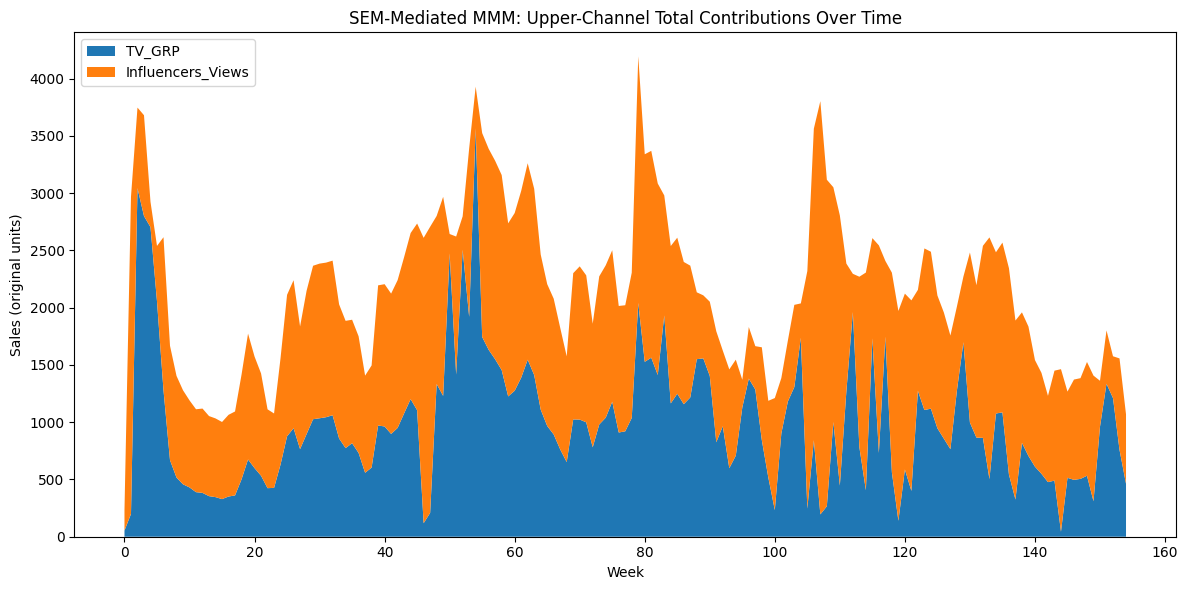

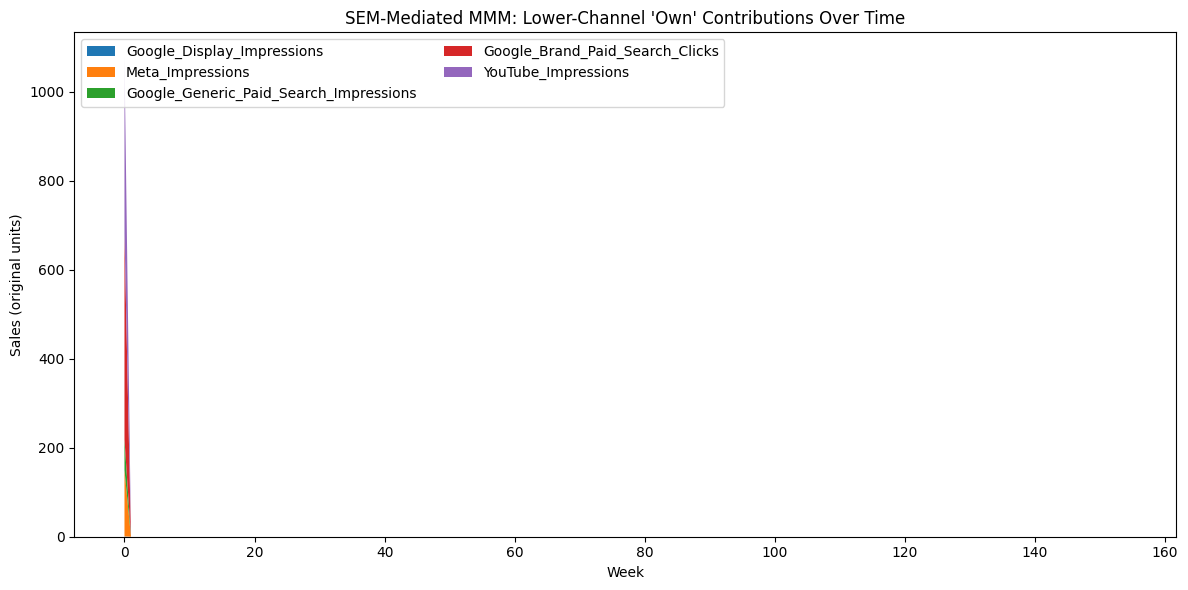

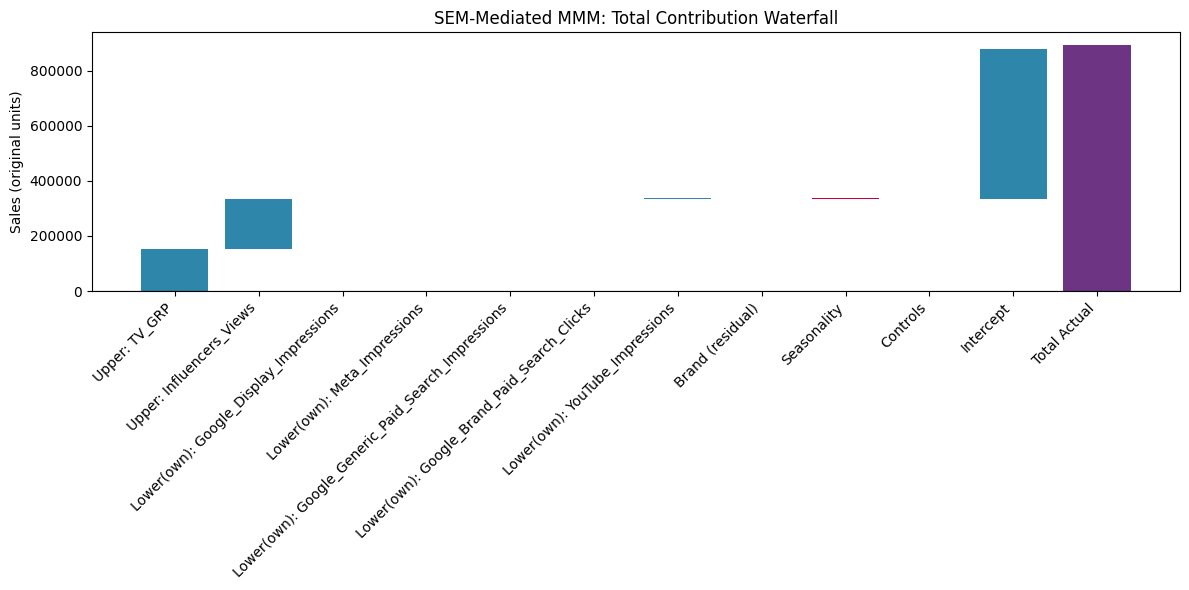

In [ ]:
# -------------------- PLOTS: DECOMPOSITION --------------------
plt.figure(figsize=(12, 6))
upper_stack = np.row_stack([contrib_upper_total[ch] for ch in upper_channels])
plt.stackplot(range(T), upper_stack, labels=upper_channels)
plt.title("SEM-Mediated MMM: Upper-Channel Total Contributions Over Time")
plt.xlabel("Week")
plt.ylabel("Sales (original units)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("sem_mediated_upper_contributions_timeseries.png", dpi=160)

plt.figure(figsize=(12, 6))
lower_stack = np.row_stack([contrib_lower_own[ch] for ch in lower_channels])
plt.stackplot(range(T), lower_stack, labels=lower_channels)
plt.title("SEM-Mediated MMM: Lower-Channel 'Own' Contributions Over Time")
plt.xlabel("Week")
plt.ylabel("Sales (original units)")
plt.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.savefig("sem_mediated_lower_contributions_timeseries.png", dpi=160)

# Waterfall: totals over time
upper_sums = [np.sum(contrib_upper_total[ch]) for ch in upper_channels]
lower_own_sums = [np.sum(contrib_lower_own[ch]) for ch in lower_channels]
brand_resid_sum = float(np.sum(contrib_brand_residual))
season_sum = float(np.sum(contrib_seasonality))
controls_sum = float(np.sum(contrib_controls))
intercept_sum = float(np.sum(contrib_intercept))
total_actual = float(np.sum(y_actual))

labels = (
    [f"Upper: {ch}" for ch in upper_channels]
    + [f"Lower(own): {ch}" for ch in lower_channels]
    + ["Brand (residual)", "Seasonality", "Controls", "Intercept", "Total Actual"]
)
values_no_total = upper_sums + lower_own_sums + [brand_resid_sum, season_sum, controls_sum, intercept_sum]

plt.figure(figsize=(12, 6))
ax = plt.gca()
waterfall(ax, labels, values_no_total + [total_actual], "SEM-Mediated MMM: Total Contribution Waterfall")
plt.tight_layout()
plt.savefig("sem_mediated_waterfall.png", dpi=160)

print("Saved figures: sem_mediated_actual_vs_pred.png, sem_mediated_upper_contributions_timeseries.png, sem_mediated_lower_contributions_timeseries.png, sem_mediated_waterfall.png")

# Basic model

In [ ]:
# BASIC MMM (PyMC 5) — Upgraded: Adstock + Hill + Fourier + Brand + Controls
# --------------------------------------------------------------------------
# Mirrors SEM sales equation transforms without mediation paths.
#
# Outputs:
#   - Posterior predictive mean vs actual (PNG)
#   - R2, MAPE
#   - Decomposition time series (upper, lower)
#   - Waterfall of total contributions
#
# Requirements: pip install pymc arviz pandas numpy matplotlib openpyxl xarray

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import xarray as xr
import warnings
import pytensor.tensor as pt

warnings.filterwarnings("ignore")

In [ ]:
# -------------------- USER SETTINGS --------------------
DATA_URL = "https://github.com/oj3v0ns/MMM/raw/01b4ffe457af67b60e2cc414c4171dd8d3e9a15f/Project%20Input%20Data.xlsx"

upper_channels = ["TV_GRP", "Influencers_Views"]
lower_channels = [
    "Google_Display_Impressions",
    "Meta_Impressions",
    "Google_Generic_Paid_Search_Impressions",
    "Google_Brand_Paid_Search_Clicks",
    "YouTube_Impressions",
]
dv_col = "Accounts Subscriptions"
brand_col = "brand_consideration"

# Transform settings
ADSTOCK_WINDOW_WEEKS = 13
FOURIER_ORDER_K = 3
SEASONAL_PERIOD = 52

# Sampling
random_seed = 2026
draws = 1500
tune = 1500
target_accept = 0.9
chains = 4

In [ ]:
# -------------------- HELPERS --------------------
def load_and_prepare(url, uppers, lowers, dv, brand):
    df = pd.read_excel(url, engine="openpyxl")
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    need = uppers + lowers + [dv, brand]
    missing = [c for c in need if c not in numeric_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    known = set(need)
    control_cols = [c for c in numeric_df.columns if c not in known]
    numeric_df = numeric_df.dropna(subset=need)

    return numeric_df, control_cols

def zscore(df, cols):
    means = df[cols].mean()
    stds = df[cols].std(ddof=0).replace(0, 1.0)
    z = (df[cols] - means) / stds
    return z, means, stds

def scale_nonneg_unit(x):
    """Map array to [0,1] robustly for Hill; avoids negatives/outliers."""
    x = np.asarray(x, dtype=float)
    lo = np.nanmin(x)
    hi = np.nanpercentile(x, 98)
    if hi - lo <= 0:
        return np.zeros_like(x), lo, hi
    return (x - lo) / (hi - lo), lo, hi

def build_fourier(T, K=3, period=52):
    t = np.arange(T)
    X = []
    for k in range(1, K+1):
        X.append(np.sin(2*np.pi*k*t/period))
        X.append(np.cos(2*np.pi*k*t/period))
    X = np.column_stack(X) if len(X) > 0 else np.zeros((T, 0))
    return X

def build_lag_matrix(x, max_lag):
    """Return (T, max_lag) where col l is x shifted by l (pad with 0)."""
    x = np.asarray(x).reshape(-1)
    T = len(x)
    mat = np.zeros((T, max_lag))
    for l in range(max_lag):
        if l == 0:
            mat[:, l] = x
        else:
            mat[l:, l] = x[:-l]
    return mat

# --- PyTensor ops for transformations (replace pm.math.*) ---
def build_adstock_from_lagmat(lag_mat, theta):
    """lag_mat: (T, W); theta in (0,1); returns (T,) adstock."""
    W = lag_mat.shape[1]
    w = pt.pow(theta, pt.arange(W))  # (W,)
    return pt.dot(lag_mat, w)        # (T,)

def hill_saturation(x, alpha, k, eps=1e-8):
    """x >= 0; returns (0,1) saturation."""
    x_pos = pt.maximum(x, 0.0) + eps
    num = pt.pow(x_pos, alpha)
    den = num + pt.pow(pt.maximum(k, eps), alpha)
    return num / (den + eps)

def compute_r2_mape(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
    return r2, mape

def posterior_mean(obj, name):
    return obj.posterior[name].mean(dim=("chain", "draw")).values

def posterior_pred_mean(ppc, name):
    da = ppc.predictions[name]
    return np.asarray(da.mean(dim=("chain", "draw"))).reshape(-1)

def waterfall(ax, labels, values, title):
    colors = [("#2E86AB" if v >= 0 else "#C70039") for v in values[:-1]] + ["#6C3483"]
    running = [0]
    for v in values[:-1]:
        running.append(running[-1] + v)
    for i, v in enumerate(values[:-1]):
        ax.bar(labels[i], v, bottom=running[i], color=colors[i])
    ax.bar(labels[-1], values[-1], color=colors[-1])
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Sales (original units)")
    ax.set_xticklabels(labels, rotation=45, ha="right")

In [ ]:
# -------------------- LOAD & PREP --------------------
df, control_cols = load_and_prepare(DATA_URL, upper_channels, lower_channels, dv_col, brand_col)

# Drop first 2 weeks to align with SEM (which uses lags 1-2)
df = df.iloc[2:].reset_index(drop=True)

# Standardize DV & Brand (observed predictors)
y_z, y_mean, y_std = zscore(df, [dv_col])
b_z, b_mean, b_std = zscore(df, [brand_col])
Yz = y_z.values.reshape(-1)
Bz = b_z.values.reshape(-1)

# Controls standardized (for stability)
if len(control_cols) > 0:
    X_c_z, c_mean, c_std = zscore(df, control_cols)
    Cz = X_c_z.values
else:
    Cz = np.zeros((len(df), 0))

T = len(df)
n_c = Cz.shape[1]

# Non-negative scaled for adstock+hill on media (upper & lower)
U_nonneg = []
L_nonneg = []
for ch in upper_channels:
    xi, _, _ = scale_nonneg_unit(df[ch].values)
    U_nonneg.append(xi)
for ch in lower_channels:
    xj, _, _ = scale_nonneg_unit(df[ch].values)
    L_nonneg.append(xj)
U_nonneg = np.column_stack(U_nonneg)
L_nonneg = np.column_stack(L_nonneg)

n_u = U_nonneg.shape[1]
n_l = L_nonneg.shape[1]

# Adstock lag matrices
U_lagmats = [build_lag_matrix(U_nonneg[:, i], ADSTOCK_WINDOW_WEEKS) for i in range(n_u)]
L_lagmats = [build_lag_matrix(L_nonneg[:, j], ADSTOCK_WINDOW_WEEKS) for j in range(n_l)]

# Fourier seasonality
S_fourier = build_fourier(T, K=FOURIER_ORDER_K, period=SEASONAL_PERIOD)
n_seas = S_fourier.shape[1]

In [ ]:
# -------------------- MODEL --------------------
with pm.Model() as basic_up_model:
    # Shared Data nodes
    Yz_v = pm.Data("Yz", Yz)
    Bz_v = pm.Data("Bz", Bz)
    Cz_v = pm.Data("Cz", Cz)
    S_fourier_v = pm.Data("S_fourier", S_fourier)

    # Wrap lag matrices for graph ops
    U_lagdat = [pm.Data(f"U_lagmat_{i}", U_lagmats[i]) for i in range(n_u)]
    L_lagdat = [pm.Data(f"L_lagmat_{j}", L_lagmats[j]) for j in range(n_l)]

    # Media transform parameters
    theta_u = pm.Beta("theta_u", alpha=2.0, beta=2.0, shape=n_u)
    theta_l = pm.Beta("theta_l", alpha=2.0, beta=2.0, shape=n_l)
    alpha_u = pm.HalfNormal("alpha_u", sigma=1.0, shape=n_u) + 0.5
    alpha_l = pm.HalfNormal("alpha_l", sigma=1.0, shape=n_l) + 0.5
    k_u     = pm.HalfNormal("k_u", sigma=1.0, shape=n_u) + 1e-3
    k_l     = pm.HalfNormal("k_l", sigma=1.0, shape=n_l) + 1e-3

    # Build transformed regressors
    U_trans = []
    for i in range(n_u):
        ad_u = build_adstock_from_lagmat(U_lagdat[i], theta_u[i])
        su   = hill_saturation(ad_u, alpha_u[i], k_u[i])
        U_trans.append(su)
    L_trans = []
    for j in range(n_l):
        ad_l = build_adstock_from_lagmat(L_lagdat[j], theta_l[j])
        sl   = hill_saturation(ad_l, alpha_l[j], k_l[j])
        L_trans.append(sl)

    U_trans = pt.stack(U_trans, axis=1)  # (T, n_u)
    L_trans = pt.stack(L_trans, axis=1)  # (T, n_l)

    # Coefficients (positive priors for interpretability)
    beta_u = pm.HalfNormal("beta_u", sigma=1.0, shape=n_u)
    beta_l = pm.HalfNormal("beta_l", sigma=1.0, shape=n_l)
    beta_b = pm.HalfNormal("beta_b", sigma=1.0)  # brand positive

    # Seasonality & controls
    S_s = pm.Normal("S_s", 0.0, 0.5, shape=n_seas)
    if n_c > 0:
        gamma = pm.Normal("gamma", 0.0, 1.0, shape=n_c)
    a = pm.Normal("a", 0.0, 1.0)
    sigma = pm.HalfNormal("sigma", 1.0)

    mu = (
        a
        + pt.dot(U_trans, beta_u)
        + pt.dot(L_trans, beta_l)
        + Bz_v * beta_b
        + pt.dot(S_fourier_v, S_s)
    )
    if n_c > 0:
        mu = mu + pt.dot(Cz_v, gamma)

    pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Yz_v)

    trace = pm.sample(
        draws=draws, tune=tune, chains=chains,
        target_accept=target_accept, random_seed=random_seed, progressbar=True
    )
    ppc = pm.sample_posterior_predictive(trace, predictions=True, random_seed=random_seed)

Output()

ERROR:pymc.stats.convergence:There were 16 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

[Basic Upgraded] R² = 0.883 | MAPE = 6.56%


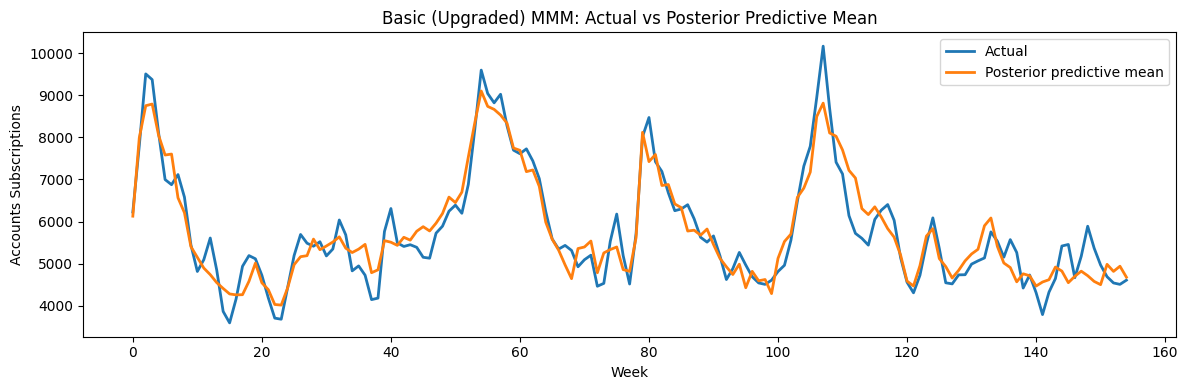

In [ ]:
# -------------------- DIAGNOSTICS --------------------
y_pred_z = posterior_pred_mean(ppc, "y_obs")
y_pred = y_pred_z * float(y_std[dv_col]) + float(y_mean[dv_col])
y_actual = df[dv_col].values

r2, mape = compute_r2_mape(y_actual, y_pred)
print(f"[Basic Upgraded] R² = {r2:.3f} | MAPE = {mape:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(y_actual, label="Actual", lw=2)
plt.plot(y_pred, label="Posterior predictive mean", lw=2)
plt.title("Basic (Upgraded) MMM: Actual vs Posterior Predictive Mean")
plt.xlabel("Week")
plt.ylabel("Accounts Subscriptions")
plt.legend()
plt.tight_layout()
plt.savefig("basic_upgraded_actual_vs_pred.png", dpi=160)

Saved figures: basic_upgraded_actual_vs_pred.png, basic_upgraded_upper_contributions_timeseries.png, basic_upgraded_lower_contributions_timeseries.png, basic_upgraded_waterfall.png


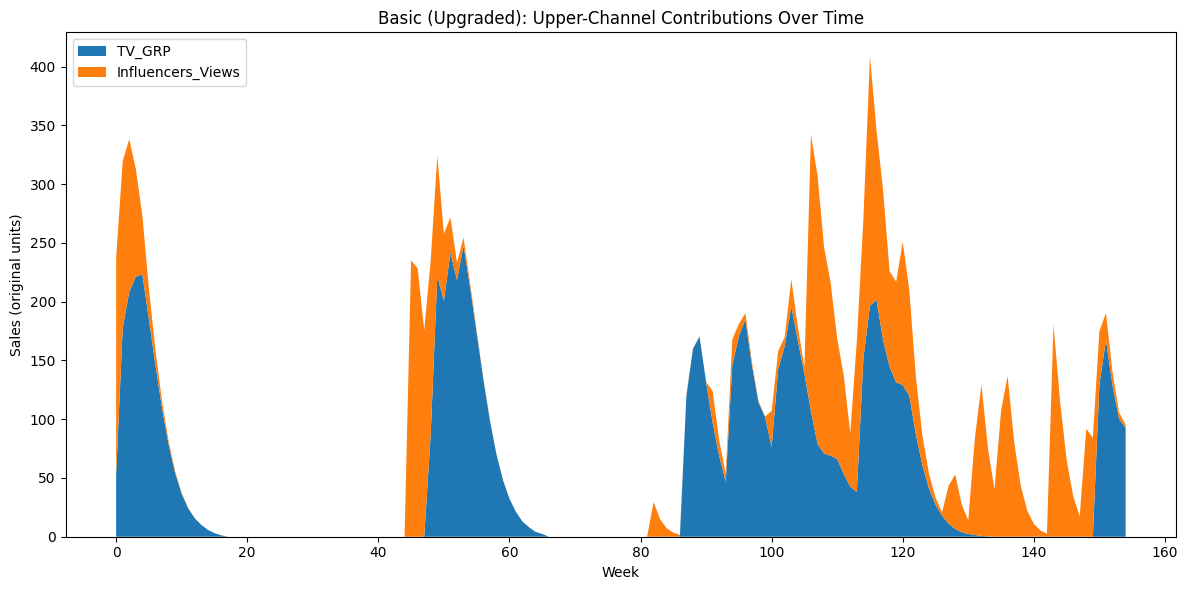

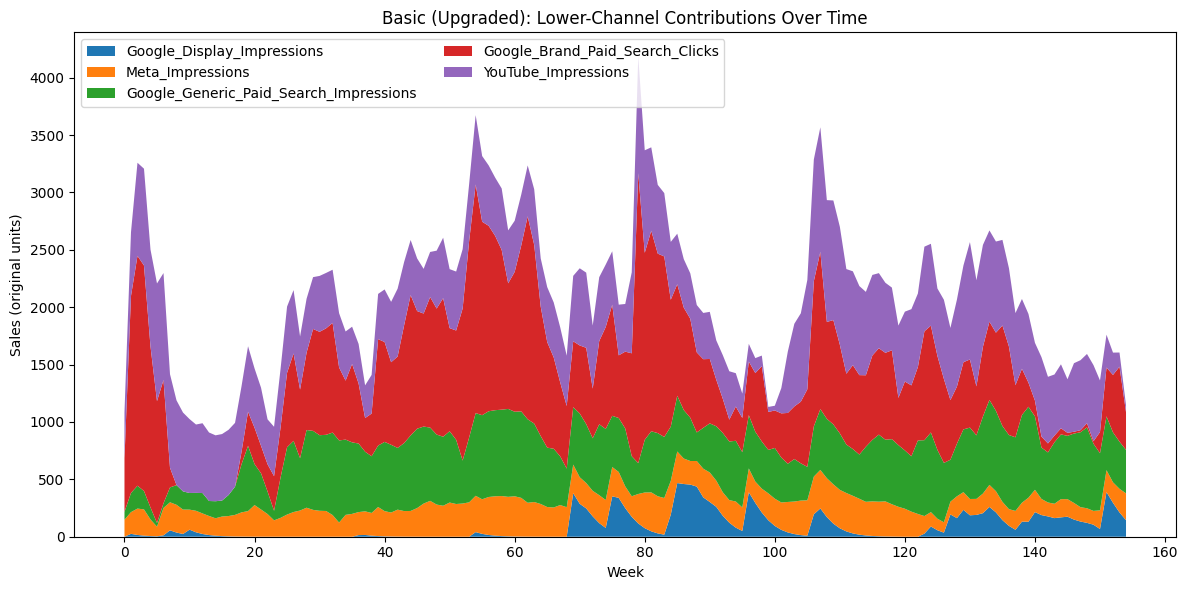

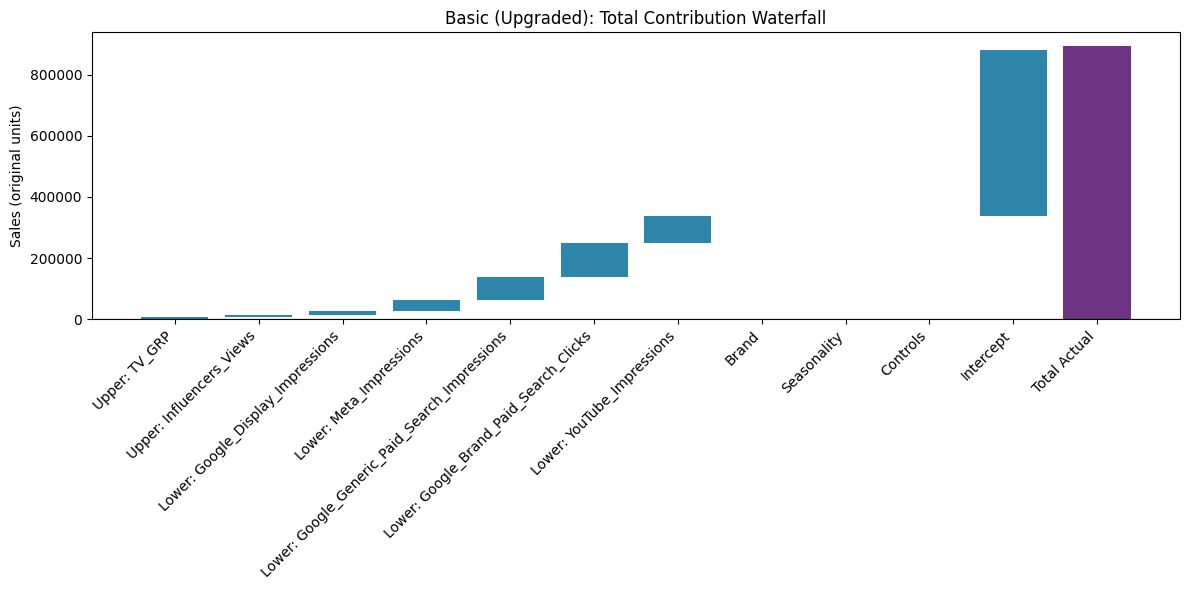

In [ ]:
# -------------------- DECOMPOSITION --------------------
coef = {}
for name in ["a","beta_u","beta_l","beta_b","S_s"]:
    coef[name] = posterior_mean(trace, name)
if n_c > 0:
    coef["gamma"] = posterior_mean(trace, "gamma")

theta_u_m = posterior_mean(trace, "theta_u")
theta_l_m = posterior_mean(trace, "theta_l")
alpha_u_m = posterior_mean(trace, "alpha_u")
alpha_l_m = posterior_mean(trace, "alpha_l")
k_u_m = posterior_mean(trace, "k_u")
k_l_m = posterior_mean(trace, "k_l")

def adstock_numpy(lagmat, theta):
    W = lagmat.shape[1]
    w = theta ** np.arange(W)
    return lagmat @ w

U_trans_np = []
for i in range(n_u):
    ad = adstock_numpy(U_lagmats[i], theta_u_m[i])
    sat = (np.maximum(ad, 0.0) ** alpha_u_m[i]) / (np.maximum(ad, 0.0) ** alpha_u_m[i] + (k_u_m[i] ** alpha_u_m[i]) + 1e-8)
    U_trans_np.append(sat)
U_trans_np = np.column_stack(U_trans_np)

L_trans_np = []
for j in range(n_l):
    ad = adstock_numpy(L_lagmats[j], theta_l_m[j])
    sat = (np.maximum(ad, 0.0) ** alpha_l_m[j]) / (np.maximum(ad, 0.0) ** alpha_l_m[j] + (k_l_m[j] ** alpha_l_m[j]) + 1e-8)
    L_trans_np.append(sat)
L_trans_np = np.column_stack(L_trans_np)

ys = float(y_std[dv_col])
ym = float(y_mean[dv_col])

contrib_upper = {ch: (coef["beta_u"][i] * U_trans_np[:, i]) * ys for i, ch in enumerate(upper_channels)}
contrib_lower = {ch: (coef["beta_l"][j] * L_trans_np[:, j]) * ys for j, ch in enumerate(lower_channels)}
contrib_brand = (coef["beta_b"] * Bz) * ys
contrib_seasonality = (S_fourier @ coef["S_s"]) * ys
contrib_controls = (Cz @ coef["gamma"]) * ys if n_c > 0 else np.zeros(T)
contrib_intercept = np.full(T, coef["a"] * ys + ym)

# Time-series plots
plt.figure(figsize=(12, 6))
stack_u = np.row_stack([contrib_upper[ch] for ch in upper_channels])
plt.stackplot(range(T), stack_u, labels=upper_channels)
plt.title("Basic (Upgraded): Upper-Channel Contributions Over Time")
plt.xlabel("Week")
plt.ylabel("Sales (original units)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("basic_upgraded_upper_contributions_timeseries.png", dpi=160)

plt.figure(figsize=(12, 6))
stack_l = np.row_stack([contrib_lower[ch] for ch in lower_channels])
plt.stackplot(range(T), stack_l, labels=lower_channels)
plt.title("Basic (Upgraded): Lower-Channel Contributions Over Time")
plt.xlabel("Week")
plt.ylabel("Sales (original units)")
plt.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.savefig("basic_upgraded_lower_contributions_timeseries.png", dpi=160)

# Waterfall
upper_sums = [np.sum(contrib_upper[ch]) for ch in upper_channels]
lower_sums = [np.sum(contrib_lower[ch]) for ch in lower_channels]
season_sum = float(np.sum(contrib_seasonality))
controls_sum = float(np.sum(contrib_controls))
intercept_sum = float(np.sum(contrib_intercept))
total_actual = float(np.sum(y_actual))

labels = (
    [f"Upper: {ch}" for ch in upper_channels]
    + [f"Lower: {ch}" for ch in lower_channels]
    + ["Brand", "Seasonality", "Controls", "Intercept", "Total Actual"]
)
values_no_total = upper_sums + lower_sums + [float(np.sum(contrib_brand)), season_sum, controls_sum, intercept_sum]

plt.figure(figsize=(12, 6))
ax = plt.gca()
waterfall(ax, labels, values_no_total + [total_actual], "Basic (Upgraded): Total Contribution Waterfall")
plt.tight_layout()
plt.savefig("basic_upgraded_waterfall.png", dpi=160)

print("Saved figures: basic_upgraded_actual_vs_pred.png, basic_upgraded_upper_contributions_timeseries.png, basic_upgraded_lower_contributions_timeseries.png, basic_upgraded_waterfall.png")

# Comparison

In [ ]:
# ================================================================
# LOO + WAIC Model Comparison Between SEM and Basic Upgraded MMM
# PyMC v5 compatible, using pm.to_inference_data()
# ================================================================

import arviz as az
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Build ArviZ inference data (PyMC 5 syntax)
# ----------------------------------------------------------

# SEM model
idata_sem = pm.to_inference_data(
    trace=trace,                     # SEM trace
    posterior_predictive=ppc,        # SEM PPC
    model=sem_model
)

# Basic upgraded model
idata_basic = pm.to_inference_data(
    trace=trace,
    posterior_predictive=ppc,
    model=basic_up_model
)

# ----------------------------------------------------------
# Compute WAIC + LOO
# ----------------------------------------------------------

waic_sem = az.waic(idata_sem)
waic_basic = az.waic(idata_basic)

loo_sem = az.loo(idata_sem)
loo_basic = az.loo(idata_basic)

print("========== WAIC ==========")
print("SEM WAIC:", waic_sem.waic)
print("Basic WAIC:", waic_basic.waic)
print()

print("========== LOO ==========")
print("SEM LOO:", loo_sem.loo)
print("Basic LOO:", loo_basic.loo)
print()

# ----------------------------------------------------------
# Model Comparison Tables (preferred)
# ----------------------------------------------------------

print("======== WAIC Comparison ========")
cmp_waic = az.compare({"SEM": idata_sem, "Basic": idata_basic}, ic="waic")
print(cmp_waic)
print()

print("======== LOO Comparison ========")
cmp_loo = az.compare({"SEM": idata_sem, "Basic": idata_basic}, ic="loo")
print(cmp_loo)
print()

# ----------------------------------------------------------
# Plot Comparison (Optional)
# ----------------------------------------------------------

az.plot_compare(cmp_loo)
plt.tight_layout()
plt.show()

TypeError: log likelihood not found in inference data object